# AIRLINE PASSENGER SATISFACTION ANALYSIS
## -Understanding Factors Influencing Customer Satisfaction in Airlines

### Introduction

##### The airline industry is highly competitive, and customer satisfaction plays a crucial role in retaining passengers and improving service quality. Airlines collect passenger feedback on various aspects such as seat comfort, online booking, inflight services, cleanliness, and delays.This project analyzes passenger feedback data collected from airline customers. The dataset contains demographic information, travel details, service ratings, delay information, and passenger satisfaction status.The primary objective is to identify the factors that influence passenger satisfaction and provide recommendations that can help airlines improve customer experience.



#### Project Objectives:

##### • Understand passenger satisfaction
##### • Analyze factors affecting satisfaction
##### • Identify customer segments
##### • Study travel delays
##### • Compare travel classes
##### • Evaluate service ratings
##### • Generate business recommendations

#### Dataset Description

###### The Airline Passenger Dataset is taken from Google Dataset Search containing total 25976 records and 24 feautres.

### Dataset Feature Legend
To ensure a rigorous analytical workflow, the features available in `airline.csv` are documented below:

| Column Name | Type | Description / Values |
| :--- | :--- | :--- |
| **id** | Numerical | Unique identifier for each passenger |
| **Gender** | Categorical | Binary gender orientation (Male, Female) |
| **Customer Type** | Categorical | Loyalty tier (Loyal Customer, Disloyal Customer) |
| **Age** | Numerical | Actual age of the passenger |
| **Type of Travel** | Categorical | Purpose of flight (Business travel, Personal Travel) |
| **Class** | Categorical | Travel cabin category (Business, Eco, Eco Plus) |
| **Flight Distance** | Numerical | Total distance of the flight path in miles |
| **Inflight wifi service** to **Cleanliness** | Categorical (Ordinal) | Customer satisfaction score from 0 (Not Applicable) to 5 (Excellent) |
| **Departure Delay in Minutes** | Numerical | Minutes delayed at departure |
| **Arrival Delay in Minutes** | Numerical | Minutes delayed at landing |
| **satisfaction** | Categorical | Target class (satisfied, neutral/dissatisfied) |











### 1. Data Loading and Initial Overview

##### Import Required Libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

- **NumPy (`numpy`)** – Used for numerical computations and mathematical operations.
- **Pandas (`pandas`)** – Used for data loading, cleaning, manipulation, and analysis.
- **Matplotlib (`matplotlib.pyplot`)** – Used to create basic static data visualizations.
- **Seaborn (`seaborn`)** – Used for creating attractive statistical charts and visualizations.
- **Plotly Express (`plotly.express`)** – Used to create interactive and high-level visualizations.
- **Plotly Graph Objects (`plotly.graph_objects`)** – Used for building customized and advanced interactive charts.

##### Load Dataset

In [12]:
df = pd.read_csv(r"C:\Users\USER\Downloads\airline.csv")

##### Display First Five Records

In [17]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,...,2,2,2,2,4,2,4,0,20.0,satisfied


##### Dataset Shape

In [20]:
df.shape

(25976, 24)

##### Data Types

In [23]:
df.dtypes

id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival De

##### Dataset Information

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 25976 non-null  int64  
 1   Gender                             25976 non-null  object 
 2   Customer Type                      25976 non-null  object 
 3   Age                                25976 non-null  int64  
 4   Type of Travel                     25976 non-null  object 
 5   Class                              25976 non-null  object 
 6   Flight Distance                    25976 non-null  int64  
 7   Inflight wifi service              25976 non-null  int64  
 8   Departure/Arrival time convenient  25976 non-null  int64  
 9   Ease of Online booking             25976 non-null  int64  
 10  Gate location                      25976 non-null  int64  
 11  Food and drink                     25976 non-null  int

##### Statistical Summary

In [29]:
df.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.00000,25893.000000
mean,65005.657992,39.620958,1193.788459,2.724746,3.046812,2.756775,2.977094,3.215353,3.261665,3.449222,3.357753,3.385664,3.350169,3.633238,3.314175,3.649253,3.286226,14.30609,14.740857
std,37611.526647,15.135685,998.683999,1.335384,1.533371,1.412951,1.282133,1.331506,1.355536,1.320090,1.338299,1.282088,1.318862,1.176525,1.269332,1.180681,1.319330,37.42316,37.517539
min,17.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000
25%,32170.500000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.00000,0.000000
50%,65319.500000,40.000000,849.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.00000,0.000000
75%,97584.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.00000,13.000000
max,129877.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1128.00000,1115.000000


In [264]:
#FOR CATEGORICAL COLUMNS
df.describe(include='object')

,Gender,Customer Type,Type of Travel,Class,satisfaction
count,25976,25976,25976,25976,25976
unique,2,2,2,3,2
top,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
freq,13172,21177,18038,12495,14573


##### Value Counts 

In [127]:
# CATEGORICAL COLUMNS
categorical_cols = [
    'Gender',
    'Customer Type',
    'Type of Travel',
    'Class',
    'satisfaction']

for col in categorical_cols:
  print(f"Value Counts for {col}")
  print(df[col].value_counts())
  print("\n")

Value Counts for Gender
Gender
Female    13172
Male      12804
Name: count, dtype: int64


Value Counts for Customer Type
Customer Type
Loyal Customer       21177
disloyal Customer     4799
Name: count, dtype: int64


Value Counts for Type of Travel
Type of Travel
Business travel    18038
Personal Travel     7938
Name: count, dtype: int64


Value Counts for Class
Class
Business    12495
Eco         11564
Eco Plus     1917
Name: count, dtype: int64


Value Counts for satisfaction
satisfaction
neutral or dissatisfied    14573
satisfied                  11403
Name: count, dtype: int64




In [133]:
#ORDINAL COLUMNS
ordinal_cols = ['Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness']

for col in ordinal_cols:
   print(f"Value Counts for {col}")
   print(df[col].value_counts().sort_index())
   print("\n")

Value Counts for Inflight wifi service
Inflight wifi service
0     813
1    4488
2    6490
3    6317
4    4981
5    2887
Name: count, dtype: int64


Value Counts for Departure/Arrival time convenient
Departure/Arrival time convenient
0    1381
1    3911
2    4343
3    4412
4    6334
5    5595
Name: count, dtype: int64


Value Counts for Ease of Online booking
Ease of Online booking
0    1195
1    4361
2    6030
3    5944
4    4873
5    3573
Name: count, dtype: int64


Value Counts for Gate location
Gate location
1    4429
2    4837
3    7140
4    6040
5    3530
Name: count, dtype: int64


Value Counts for Food and drink
Food and drink
0      25
1    3214
2    5395
3    5494
4    6204
5    5644
Name: count, dtype: int64


Value Counts for Online boarding
Online boarding
0     652
1    2569
2    4429
3    5313
4    7706
5    5307
Name: count, dtype: int64


Value Counts for Seat comfort
Seat comfort
1    3033
2    3632
3    4632
4    7991
5    6688
Name: count, dtype: int64


Value Count

### 2. Data Preprocessing

#### 2.1 Handling Missing Values

In [34]:
# CHECK MISSING VALUES
df.isnull().sum()

id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0
dtype: int64

###### Since only 83 values were missing in Arrival Delay in Minutes and the data contains outliers, median imputation was preferred over mean to avoid skewing the distribution.

In [37]:
# FILLING THE MISSING VALUES WITH MEADIAN
df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median(),inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_18928\3144685649.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median(),inplace=True)


In [39]:
#CHECKING IF THERE IS ANY MISSING VALUES MORE
df.isnull().sum()

id                                   0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

#### 2.2 Handling Duplicates

In [43]:
# CHECKING DUPLICATE RECORDS
df.duplicated(subset="id").sum()

0

###### No Duplicates are found in the dataset

#### 2.3 Correcting Data Types

In [49]:
# VERIFY DATA TYPES
df.dtypes

id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival De

In [240]:
# Map target variable to binary to allow for numerical correlation analysis
df['satisfaction_binary'] = df['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})

###### All columns were verified to ensure appropriate data types for analysis.

#### 2.4 Creating Derived Columns

###### Derived columns are created to simplify analysis. Here we create 2 derived columns named 'Total Delay' adding 'Departure Delay' and 'Arrival delay' and the other one named 'Age Category' using 'Age'column. 

In [141]:
# TOTAL DELAY
df['Total_Delay'] = (df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes'])

In [57]:
df['Age'].value_counts() #Checking frequency count of unique values in the column

Age
39    723
25    713
40    635
41    633
43    626
     ... 
75     15
74     14
78     11
79     10
85      8
Name: count, Length: 75, dtype: int64

In [59]:
# AGE CATEGORY
bins = [0,18,30,45,60,100]
labels = ['Teen','Young Adult','Adult','Middle Age','Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

#### 2.5 Filtering and Aggregation

In [149]:
# Definition: Passengers with more than a 30-minute arrival delay on short-distance flights
short_flight_delayed_passengers = df[(df['Flight Distance'] < 1000) & (df['Arrival Delay in Minutes'] > 30)]

print(f"\n--- Filtered Subset Analysis ---")
print(f"Number of passengers on short flights (<1000 miles) facing significant delays (>30 mins): {short_flight_delayed_passengers.shape[0]}")
print(f"Satisfaction rate within this highly frustrated filter group:")
display(short_flight_delayed_passengers['satisfaction'].value_counts(normalize=True) * 100)


--- Filtered Subset Analysis ---
Number of passengers on short flights (<1000 miles) facing significant delays (>30 mins): 2203
Satisfaction rate within this highly frustrated filter group:


satisfaction
neutral or dissatisfied    73.399909
satisfied                  26.600091
Name: proportion, dtype: float64

###### Among passengers on short flights (<1000 miles) delayed by more than 30 minutes, about 73.4% were neutral or dissatisfied, showing that significant delays have a strong negative impact on passenger satisfaction.

#### 2.6 Dataset Overview

In [20]:
data_overview = pd.DataFrame({
    'Metric': ['Total Passengers','Satisfaction Rate (%)','Average Age','Average Flight Distance','Average Arrival Delay (Minutes)'],
    'Value': [
        f"{len(df):,}",
        f"{(df['satisfaction'].eq('satisfied').mean()*100):.2f}%",
        f"{df['Age'].mean():.1f} Years",
        f"{df['Flight Distance'].mean():.1f} Miles",
        f"{df['Arrival Delay in Minutes'].mean():.1f} Minutes"]})

display(data_overview)

,Metric,Value
0,Total Passengers,"25,976"
1,Satisfaction Rate (%),43.90%
2,Average Age,39.6 Years
3,Average Flight Distance,1193.8 Miles
4,Average Arrival Delay (Minutes),14.7 Minutes


### 3. Exploratory Data Analysis (EDA) and Visualization

###### EDA is conducted to identify patterns, relationships, and trends within the airline dataset.Data visualization is the graphical representation of data using charts, graphs, and plots to make complex information easier to understand.

##### 1. PASSENGER SATISFACTION DISTRIBUTION

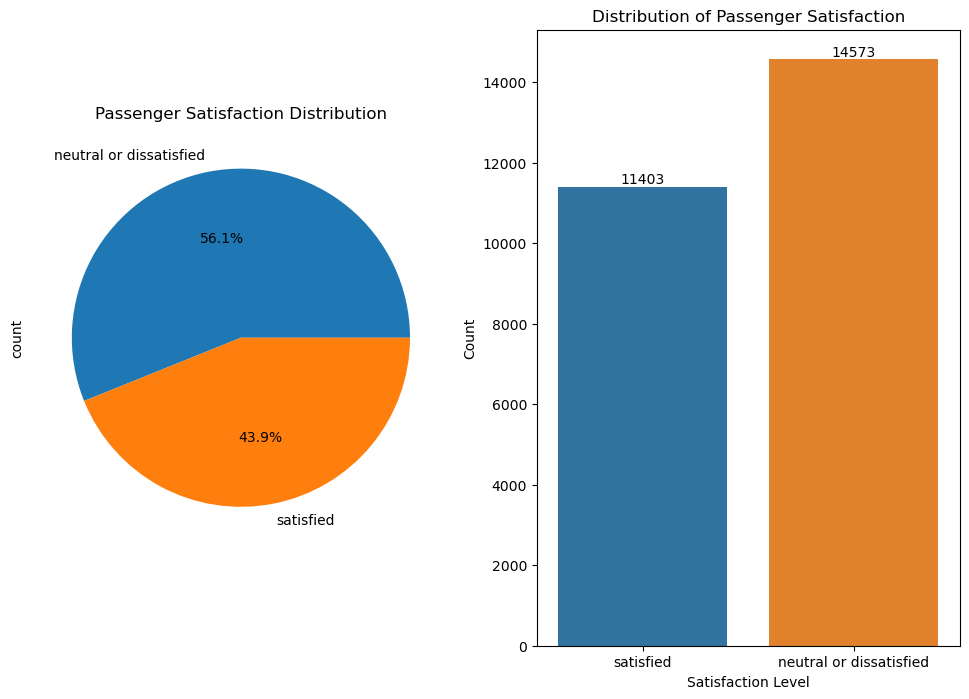

In [403]:
plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
df['satisfaction'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Passenger Satisfaction Distribution')

plt.subplot(1, 2, 2)
ax = sns.countplot(data=df, x='satisfaction',hue='satisfaction',legend=False)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribution of Passenger Satisfaction')
plt.xlabel('Satisfaction Level')
plt.ylabel('Count')
plt.show()

###### The passenger population is divided into satisfied and dissatisfied customers.Although many passengers are satisfied, a significant portion remains dissatisfied, indicating opportunities for service improvement.

##### 2.GENDER DISTRIBUTION

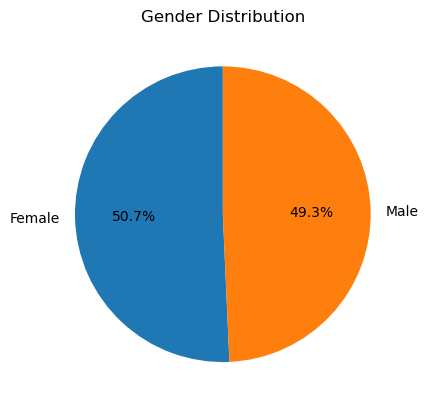

In [342]:
import matplotlib.pyplot as plt
df['Gender'].value_counts().plot( kind='pie',autopct='%1.1f%%',startangle=90)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

###### Male and female passengers are nearly equally represented.This indicates that the dataset is balanced by gender and that gender alone is unlikely to explain satisfaction differences.

##### 3. AGE DISTRIBUTION

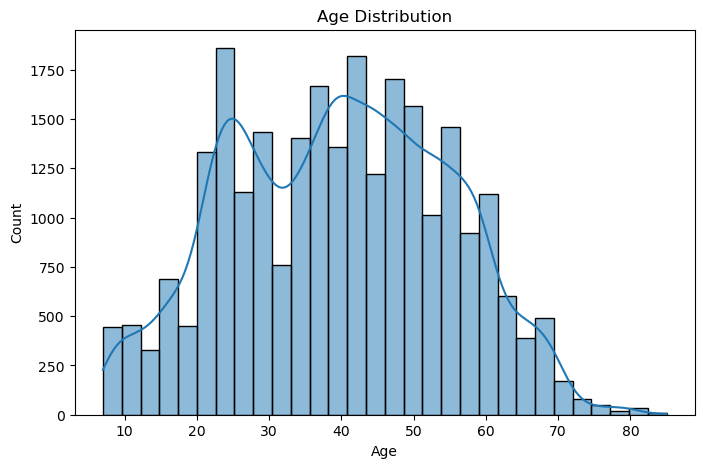

In [350]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel('Age')
plt.show()

###### Most passengers belong to the working-age group (approximately 20–60 years).Very young and elderly passengers form a smaller proportion.The age distribution appears reasonably spread without extreme concentration.

##### 4. DELAY DISTRIBUTION

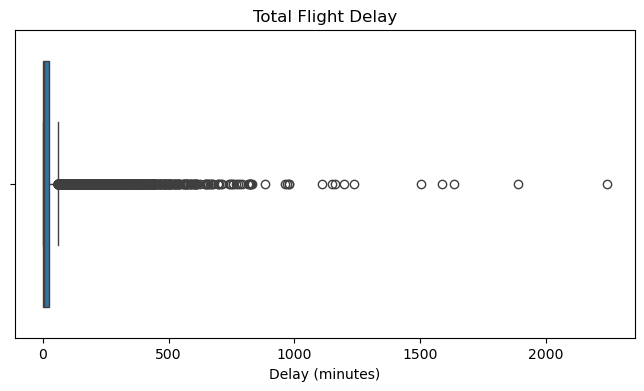

In [355]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Total_Delay'])
plt.title("Total Flight Delay")
plt.xlabel("Delay (minutes)")
plt.show()

###### Most passengers experience relatively low delays.Several extreme outliers indicate that a small number of passengers experienced very long delays.These extreme delays may strongly influence customer satisfaction.

##### 5.TRAVEL CLASS ANALYSIS

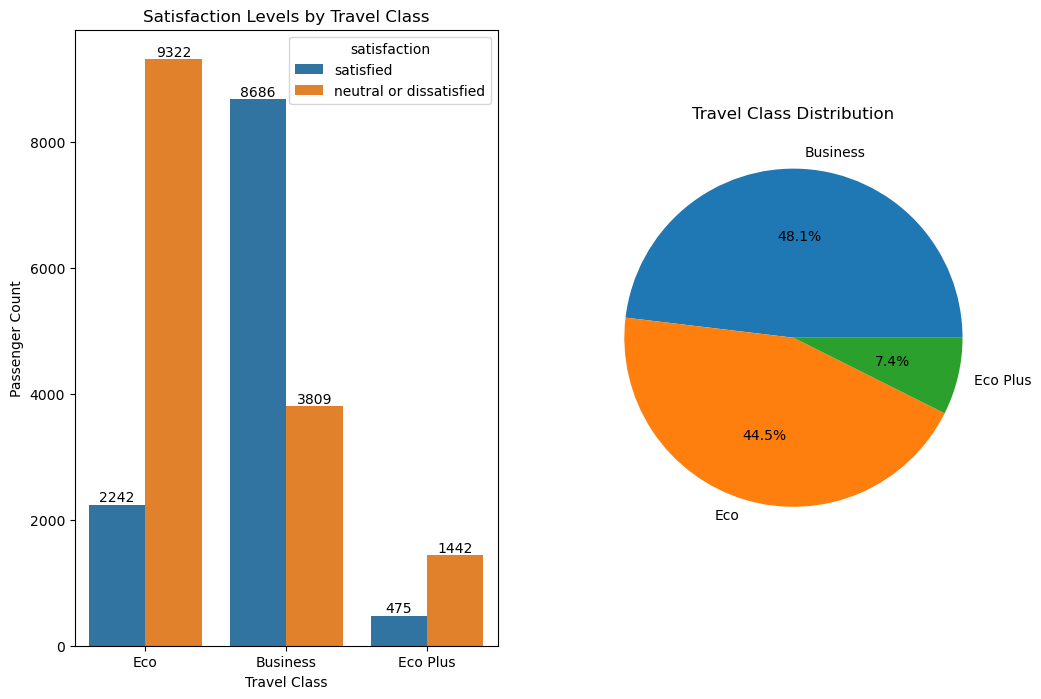

In [368]:
plt.figure(figsize=(12, 8))

plt.subplot(1,2,1)
ax = sns.countplot(x='Class', hue='satisfaction', data=df, )
for container in ax.containers:
    ax.bar_label(container)
plt.title('Satisfaction Levels by Travel Class')
plt.xlabel('Travel Class')
plt.ylabel('Passenger Count')

plt.subplot(1, 2, 2)
df['Class'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Travel Class Distribution')
plt.ylabel('')
plt.show()

###### Business Class accounts for the largest share of passengers.Business Class passengers report higher satisfaction.Economy passengers have comparatively lower satisfaction levels.Higher-quality services and comfort in premium cabins contribute to better customer experience.

##### 6. SATISFACTION ANALYSIS BY AGE GROUP/CATEGORY

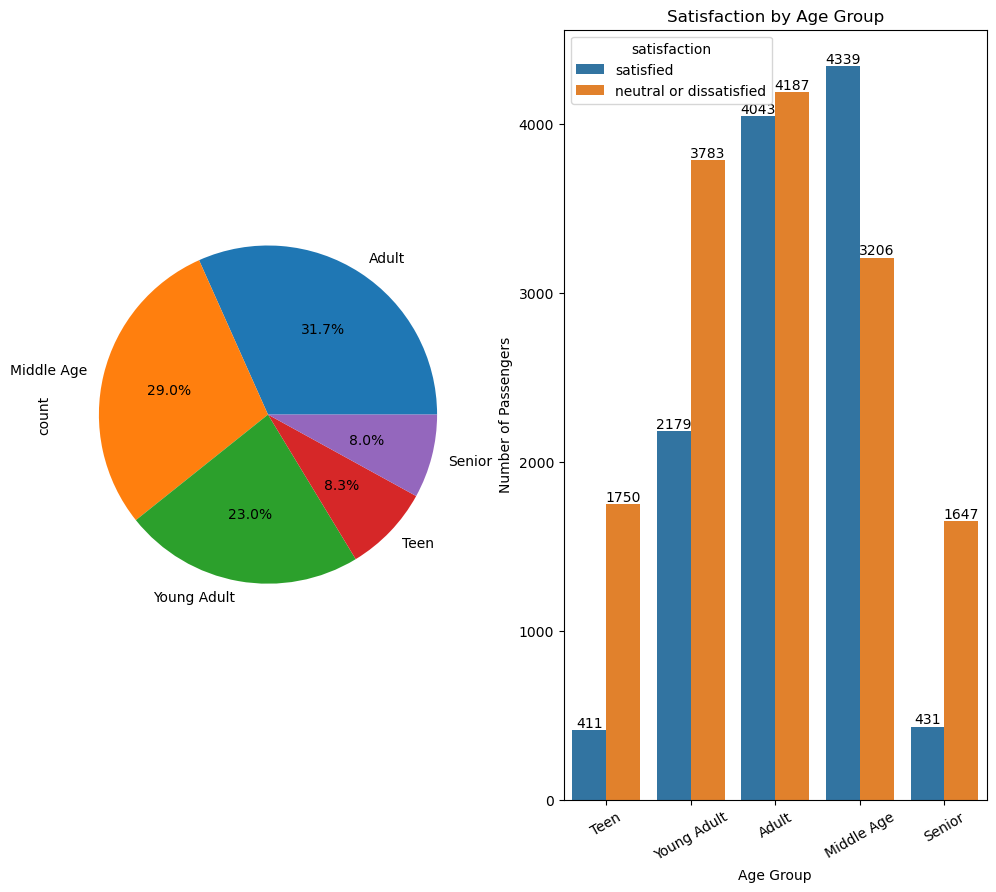

In [366]:
plt.figure(figsize=(12, 10))

plt.subplot(1, 2, 1)
df['Age_Group'].value_counts().plot.pie(autopct='%1.1f%%')

plt.subplot(1, 2, 2)
ax = sns.countplot( data=df,x='Age_Group',hue='satisfaction')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Satisfaction by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=30)
plt.show()

###### Satisfaction levels vary across age groups.Middle-aged passengers generally contribute the highest number of satisfied customers because they represent the largest customer segment.Younger and older passengers may have different service expectations.

##### 7. TYPE OF TRAVEL VS SATISFACTION

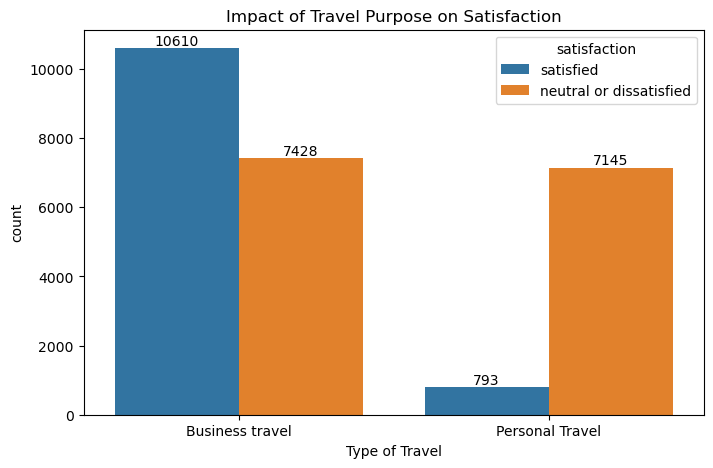

In [372]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Type of Travel', hue='satisfaction', data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Impact of Travel Purpose on Satisfaction')
plt.show()

###### Business travelers show considerably higher satisfaction.Personal travelers exhibit relatively higher dissatisfaction.Business passengers likely benefit from premium services, flexible schedules, and better travel experiences.

##### 8. FLIGHT DISTANCE BOX PLOT

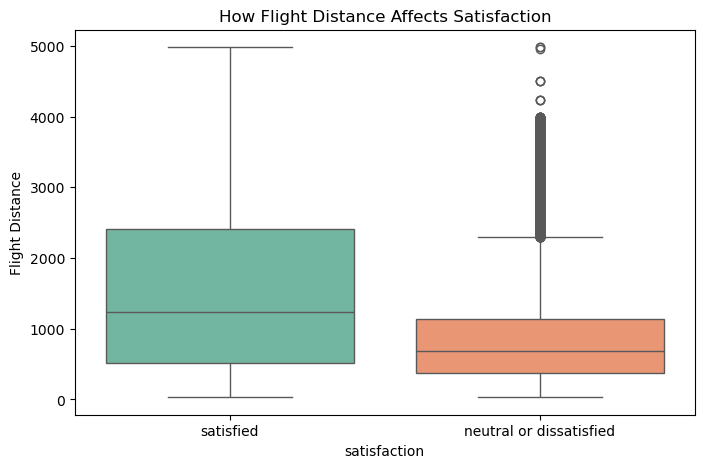

In [204]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='satisfaction', y='Flight Distance',hue = 'satisfaction',legend=False, data=df)
plt.title('How Flight Distance Affects Satisfaction')
plt.show()

###### Satisfied passengers generally travel longer distances.Longer flights are often associated with better onboard services, increasing overall satisfaction.Short-distance travelers show greater variation in satisfaction.

##### 9. CUSTOMER TYPE VS SATISFACTION

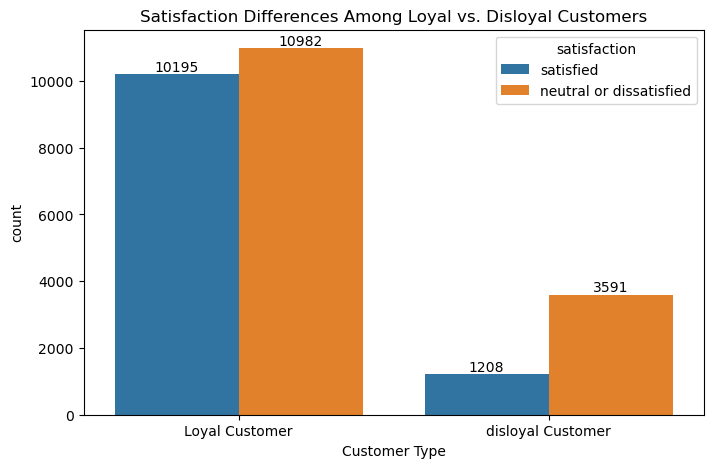

In [375]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Customer Type', hue='satisfaction', data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Satisfaction Differences Among Loyal vs. Disloyal Customers')
plt.show()

###### Loyal customers are significantly more satisfied.Disloyal customers are more likely to report dissatisfaction.Building customer loyalty directly contributes to higher satisfaction levels.

##### 10. CORRELATION HEATMAP

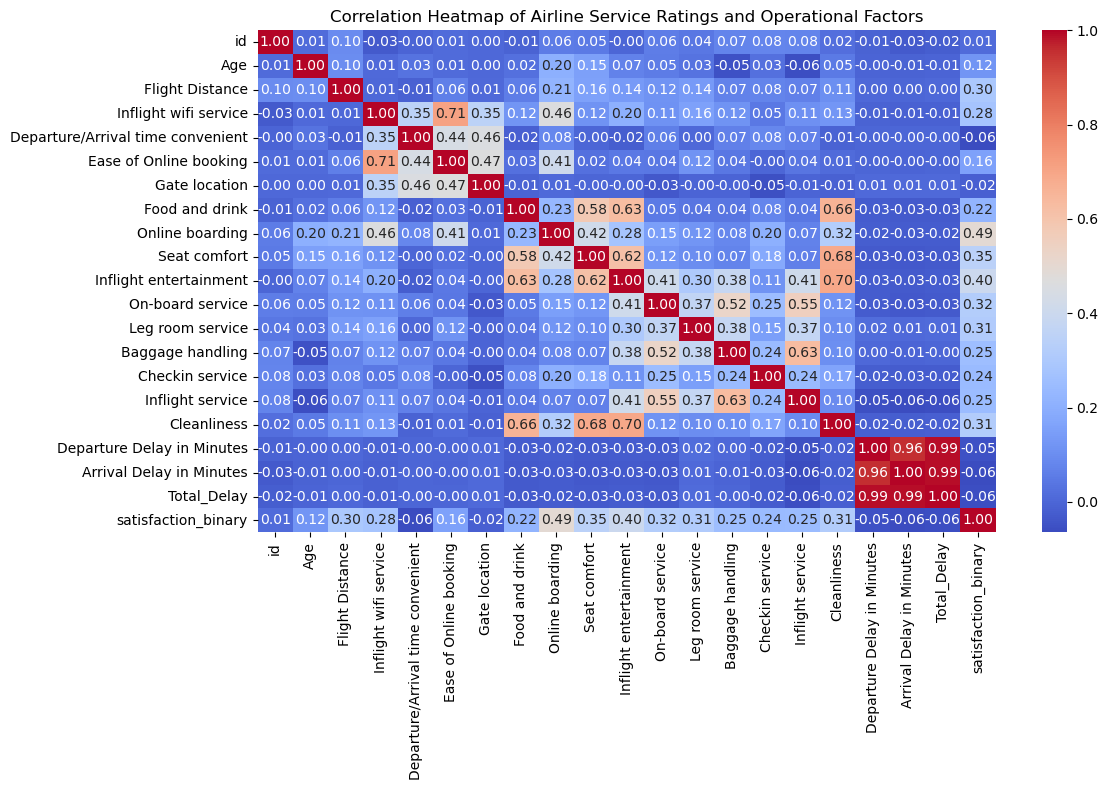

In [380]:
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=np.number).corr() 
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Airline Service Ratings and Operational Factors')
plt.tight_layout()
plt.show()

###### Arrival Delay and Departure Delay exhibit a strong positive correlation.Service quality variables such as:Seat Comfort, Cleanliness, InflightEntertainment, Online Boarding, Inflight Service show positive relationships with passenger satisfaction.Delay variables show negative relationships with satisfaction.

##### 11. RELATIONSHIP BETWEEN DEPARTURE AND ARRIVAL DELAY

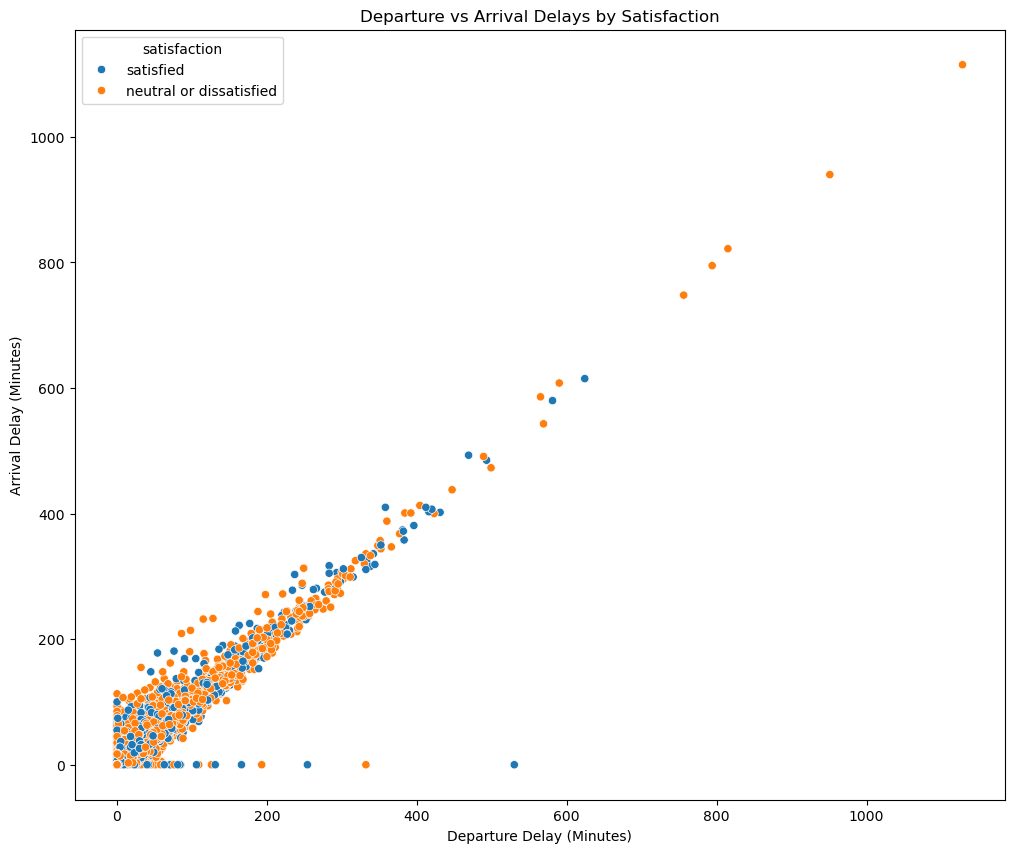

In [384]:
plt.figure(figsize=(12, 10))
sns.scatterplot(x='Departure Delay in Minutes', y='Arrival Delay in Minutes', hue='satisfaction', data=df)
plt.title('Departure vs Arrival Delays by Satisfaction')
plt.xlabel('Departure Delay (Minutes)')
plt.ylabel('Arrival Delay (Minutes)')
plt.show()

###### Departure delay and arrival delay have a strong positive linear relationship.Flights departing late usually arrive late.Satisfied passengers tend to cluster around lower delay values.

##### 12. AVERAGE SATISFACTION RATINGS BY AGE 

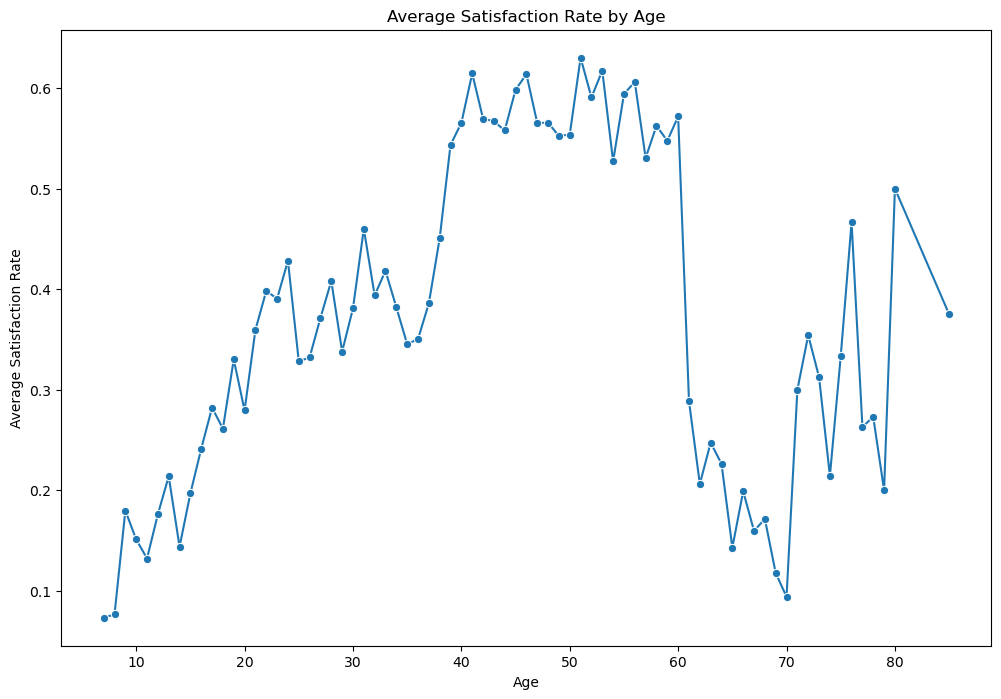

In [389]:
plt.figure(figsize=(12, 8))
age_satisfaction = df.groupby('Age')['satisfaction_binary'].mean().reset_index()
sns.lineplot(x='Age', y='satisfaction_binary', data=age_satisfaction, marker='o')
plt.title('Average Satisfaction Rate by Age')
plt.xlabel('Age')
plt.ylabel('Average Satisfaction Rate')
plt.show()

###### Services such as:Cleanliness,Seat Comfort,Inflight Service,Baggage Handling generally receive higher average ratings.Lower-rated services (often including Wi-Fi or Gate Location in airline datasets) represent opportunities for operational improvement.

##### 13.SERVICE RATINGS COMPARISON

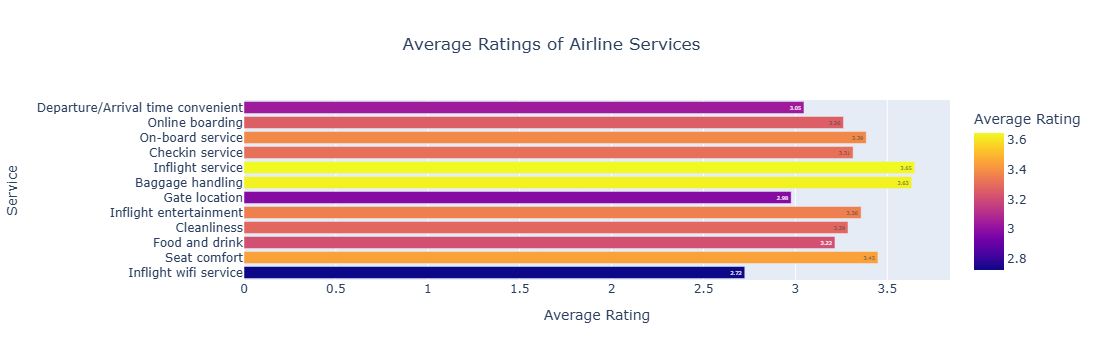

In [401]:
service_cols = ['Inflight wifi service','Seat comfort','Food and drink','Cleanliness','Inflight entertainment','Gate location',
              'Baggage handling', 'Inflight service', 'Checkin service','On-board service','Online boarding' ,'Departure/Arrival time convenient']

service_avg = df[service_cols].mean().reset_index()
service_avg.columns = ['Service', 'Average Rating']

fig = px.bar(
    service_avg,
    x='Average Rating',
    y='Service',
    orientation='h',
    color='Average Rating',
    title='Average Ratings of Airline Services',
    text_auto='.2f')

fig.update_layout(title_x=0.5)
fig.show()

###### Satisfaction changes gradually across different ages rather than abruptly.No single age group dominates satisfaction completely.Age influences satisfaction moderately compared to operational and service factors.

##### 14. CUSTOMER TYPE ACROSS TRAVEL CLASS AND TYPE OF TRAVEL

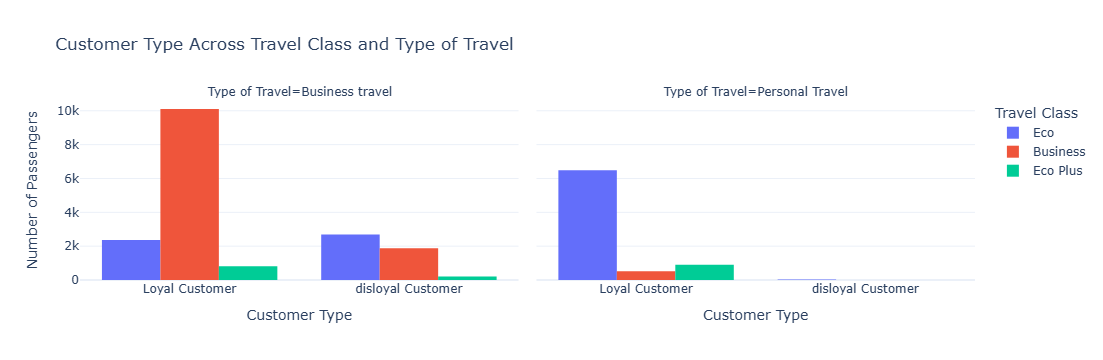

In [429]:
fig = px.histogram(df,x='Customer Type',color='Class',facet_col='Type of Travel',barmode='group',
    title='Customer Type Across Travel Class and Type of Travel',
        labels={
        'Customer Type': 'Customer Type',
        'Class': 'Travel Class',
        'Type of Travel': 'Type of Travel'})
   
fig.update_layout( template='plotly_white',
title={'text': 'Customer Type Across Travel Class and Type of Travel'},
xaxis_title='Customer Type', yaxis_title='Number of Passengers',
legend_title='Travel Class')
fig.show()

###### Loyal customers are predominantly associated with Business Travel, particularly in Business Class.Personal travelers are mainly concentrated in Economy Class, regardless of customer type.Business Class has a higher proportion of loyal customers, indicating stronger customer retention among premium passengers.Economy Plus has the fewest passengers across both travel purposes.

##### 15. TREEMAP

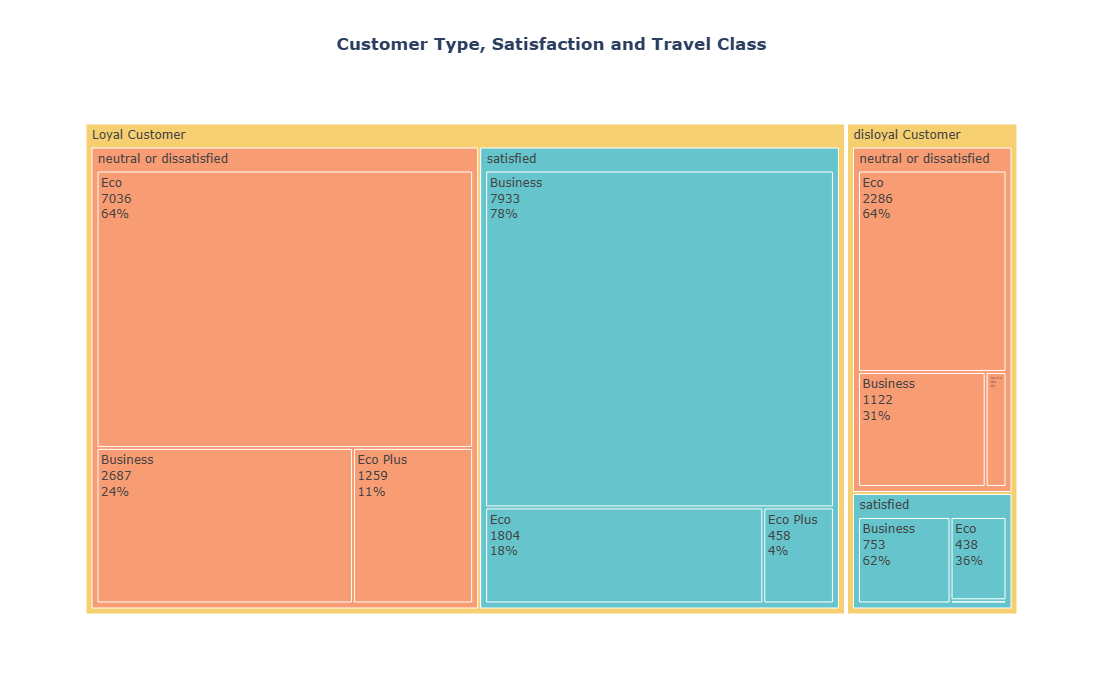

In [437]:
fig = px.treemap(df,
    path=['Customer Type', 'satisfaction', 'Class'],
    title='Customer Type, Satisfaction and Travel Class',
    color='satisfaction',
    color_discrete_sequence=px.colors.qualitative.Pastel)

fig.update_traces(
    textinfo='label+value+percent parent')

fig.update_layout(
    template='plotly_white',
    title={
        'text': '<b>Customer Type, Satisfaction and Travel Class</b>',
        'x': 0.5,
        'xanchor': 'center' },
    height=700,
    width=1000)

fig.show()

###### Loyal Business Class passengers show the highest satisfaction, while Economy Class has the largest proportion of neutral or dissatisfied passengers.

##### 16. CUSTOMER TYPE ACROSS AGE GROUPS AND TRAVEL CLASS

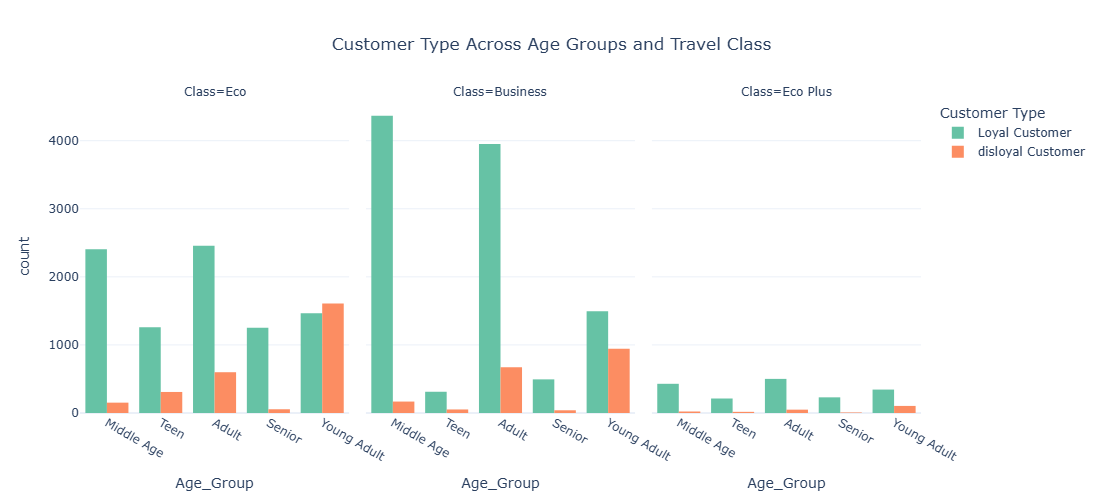

In [446]:
fig = px.histogram(
    df,x='Age_Group',color='Customer Type',facet_col='Class',barmode='group',
    title='Customer Type Across Age Groups and Travel Class',
    color_discrete_sequence=px.colors.qualitative.Set2)

fig.update_layout(
    template='plotly_white',
    title_x=0.5,
    height=500,
    width=1000)
fig.show()

###### Loyal customers are concentrated among middle-aged and adult passengers in Business Class, while Economy Class has a relatively higher share of disloyal young adult passengers.

### 4. INSIGHTS

- The airline has a relatively balanced customer base, with satisfied passengers slightly outnumbering neutral or dissatisfied passengers, indicating overall good service quality with opportunities for improvement.

- **Business Class** passengers consistently report the highest satisfaction levels, highlighting the positive impact of premium services on the overall travel experience.

- **Economy Class** has the highest proportion of dissatisfied passengers, suggesting a need to improve comfort, service quality, and onboard facilities.

- **Loyal Customers** are significantly more satisfied than disloyal customers, demonstrating the effectiveness of customer loyalty programs in enhancing passenger satisfaction.

- **Business Travelers** generally exhibit higher satisfaction than personal travelers, indicating that the airline currently meets business travel expectations more effectively.

- The majority of passengers belong to the **20–60 years** age group, making them the airline's primary customer segment.

- Service attributes such as **Seat Comfort, Inflight Entertainment, Cleanliness, Food & Drink, and Inflight Wi-Fi** have a strong positive influence on customer satisfaction.

- **Departure Delay** and **Arrival Delay** show a strong positive correlation, indicating that delays at departure usually continue until arrival.

- Most flights experience only minor delays; however, a small number of flights with significant delays negatively impact overall customer satisfaction.

- Passengers traveling longer distances generally report higher satisfaction, likely due to better onboard services and amenities available on long-haul flights.

- Middle-aged **Loyal Business Class** passengers represent the most satisfied customer segment, whereas younger, disloyal Economy Class passengers contribute more to dissatisfaction.


### CONCLUSION

This analysis explored the factors affecting airline passenger satisfaction through data preprocessing, exploratory data analysis (EDA), and visualization techniques.

The findings indicate that **travel class, customer loyalty, travel purpose, service quality, and flight delays** are the primary factors influencing passenger satisfaction. Business Class passengers, particularly loyal business travelers, exhibit the highest satisfaction levels due to superior onboard services and overall travel experience. In contrast, dissatisfaction is more common among Economy Class passengers, personal travelers, and disloyal customers, highlighting areas where service improvements are required.

The correlation analysis also reveals that operational delays have a direct impact on customer experience, while service-related features such as **Seat Comfort, Cleanliness, Inflight Entertainment, Food Quality, and Wi-Fi** play a significant role in improving passenger satisfaction.

Overall, the airline can further enhance customer satisfaction by:

- Improving service quality in Economy Class.
- Reducing departure and arrival delays.
- Strengthening customer loyalty programs.
- Investing in onboard comfort and digital services.
- Delivering a more consistent travel experience across all customer segments.

Implementing these recommendations can improve passenger satisfaction, strengthen customer loyalty, enhance operational efficiency, and increase the airline's long-term competitiveness.